# **Programa Especializado en Credit Scoring con Python**
<img src="../../figuras/logo.png" width="200"/>

## 📊 **Sesión 16: Introducción IFRS 9: LGD y EAD**

**Docente**: Enzo Infantes Zúñiga  
**Contacto**: <enzo.infantes28@gmail.com>  
**LinkedIn**: [enzo-infantes](https://www.linkedin.com/in/enzo-infantes/)

📌 **Agenda de la Sesión**

| # | Bloque | Descripción |
|---|--------|-------------|
| 1 | **LGD** | Definición, intuición económica y fórmula estándar |
| 2 | **EAD** | Definición, intuición y principales enfoques |
| 3 | **Cálculo práctico** | Implementación en Python con datos simulados |
| 4 | **Integración IFRS 9** | Rol de LGD y EAD en el cálculo de la pérdida esperada |

🎯 **Objetivos de la Sesión**

- Comprender qué mide la LGD y cómo se calcula mediante el valor presente de las recuperaciones.
- Comprender qué mide la EAD y cómo se estima la exposición al momento del incumplimiento.
- Implementar estimaciones básicas de LGD y EAD en Python.
- Conectar LGD y EAD con la fórmula de pérdida esperada bajo IFRS 9.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})

## **1. LGD: Loss Given Default**

### **1.1 ¿Qué es la LGD?**

La **LGD (Loss Given Default)** es la fracción de la exposición que el banco **pierde efectivamente** una vez que un cliente entra en incumplimiento.

> **Intuición:** Si un cliente debe 100 y, tras el proceso de cobranza, el banco recupera 40, la pérdida fue de 60 → LGD = 60%.

La LGD **no** es simplemente "1 - tasa de recuperación" nominal: hay que considerar el **valor tiempo del dinero**, los **costos del proceso de recuperación** y el **plazo** en que se producen las recuperaciones.


### **1.2 Fórmula Estándar de la LGD**

El enfoque conceptualmente correcto descuenta los flujos de recuperación:

$$
\text{LGD} = 1 - \frac{\text{VP(Recuperaciones)} - \text{VP(Costos de cobranza)}}{\text{EAD}}
$$

Donde el **Valor Presente de las Recuperaciones** se obtiene descontando cada flujo $R_t$ a una tasa $r$ (usualmente el costo de fondos del banco):

$$
\text{VP(Recuperaciones)} = \sum_{t=1}^{T} \frac{R_t}{(1+r)^t}
$$

**Componentes clave:**

| Componente | Descripción |
|---|---|
| $R_t$ | Flujo de recuperación en el período $t$ |
| $r$ | Tasa de descuento (costo de fondos) |
| Costos | Gastos legales, operativos y administrativos de cobranza |
| EAD | Exposición al momento del incumplimiento |


### **1.3 Tasas de Recuperación (RR) y su relación con LGD**

$$
\text{LGD} = 1 - RR
$$

Esta relación aplica en su versión simplificada (sin descontar). En la práctica regulatoria bajo IFRS 9, siempre se descuenta.

**Factores que determinan la LGD:**
- Tipo de producto: hipotecas (LGD baja por colateral) vs. tarjetas (LGD alta, sin garantía)
- Antigüedad del incumplimiento
- Calidad y valor del colateral
- Eficiencia del proceso de cobranza
- Ciclo económico (LGD-in-downturn bajo IFRS 9)

### **1.4 Cálculo de LGD con Descuento de Recuperaciones**

In [2]:
# ─────────────────────────────────────────────────────────────
# Ejemplo: cálculo de LGD para un crédito individual
# ─────────────────────────────────────────────────────────────

def calcular_lgd(ead, recuperaciones, tasa_descuento, costos_cobranza):
    """
    Calcula la LGD descontando los flujos de recuperación.

    Parámetros
    ----------
    ead              : float — Exposición al momento del default
    recuperaciones   : list  — Flujos de recuperación por período [R1, R2, ...]
    tasa_descuento   : float — Tasa de descuento anual (ej. 0.10 = 10%)
    costos_cobranza  : float — Costos totales del proceso de cobranza

    Retorna
    -------
    lgd : float — LGD entre 0 y 1
    """
    vp_recuperaciones = sum(
        R / (1 + tasa_descuento) ** t
        for t, R in enumerate(recuperaciones, start=1)
    )

    # costos_cobranza es ahora una lista de flujos por período
    vp_costos_cobranza = sum(
        C / (1 + tasa_descuento) ** t
        for t, C in enumerate(costos_cobranza, start=1)
    )

    perdida_neta = ead - (vp_recuperaciones - vp_costos_cobranza)
    lgd = perdida_neta / ead
    return max(0, min(1, lgd))


# ── Escenario 1: Crédito con colateral (ej. hipoteca) ──
lgd_hipoteca = calcular_lgd(
    ead=100_000,
    recuperaciones=[20_000, 40_000, 30_000],  # 3 períodos de recuperación
    tasa_descuento=0.08,
    costos_cobranza=[3_000, 5_000, 4_000]
)

# ── Escenario 2: Tarjeta de crédito (sin garantía) ──
lgd_tarjeta = calcular_lgd(
    ead=5_000,
    recuperaciones=[500, 400],               # recuperaciones bajas y cortas
    tasa_descuento=0.08,
    costos_cobranza=[200, 100]
)

print("=" * 45)
print(f" LGD Hipoteca (con colateral):   {lgd_hipoteca:.2%}")
print(f" LGD Tarjeta (sin garantía):     {lgd_tarjeta:.2%}")
print("=" * 45)

 LGD Hipoteca (con colateral):   33.61%
 LGD Tarjeta (sin garantía):     89.30%


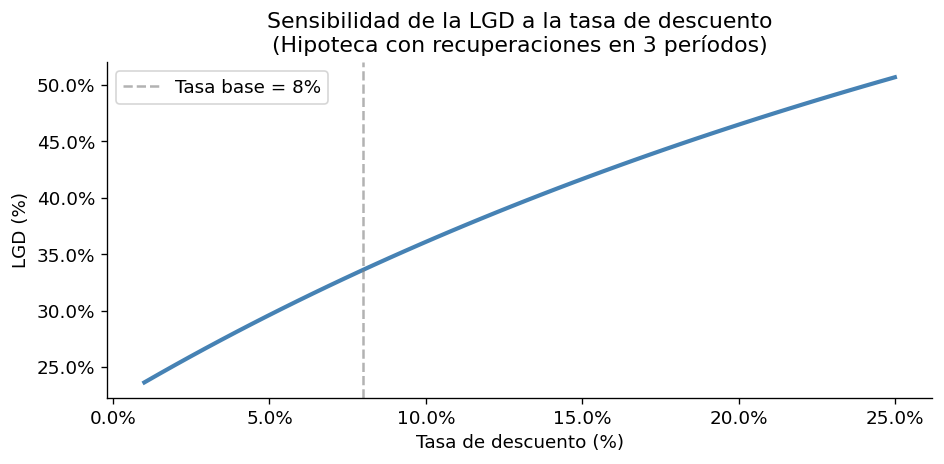


   Clave conceptual:
   A mayor tasa de descuento, el VP de las recuperaciones futuras disminuye,
   por lo tanto la LGD aumenta aunque los flujos nominales sean los mismos.



In [8]:
# ─────────────────────────────────────────────────────────────
# Sensibilidad de la LGD a la tasa de descuento
# Cuanto más alta la tasa → el VP de las recuperaciones cae → LGD sube
# ─────────────────────────────────────────────────────────────
tasas = np.linspace(0.01, 0.25, 50)

lgd_por_tasa = [
    calcular_lgd(
        ead=100_000,
        recuperaciones=[20_000, 40_000, 30_000],
        tasa_descuento=r,
        costos_cobranza=[3_000, 5_000, 4_000]
    )
    for r in tasas
]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(tasas * 100, np.array(lgd_por_tasa) * 100, color='steelblue', linewidth=2.5)
ax.set_xlabel('Tasa de descuento (%)')
ax.set_ylabel('LGD (%)')
ax.set_title('Sensibilidad de la LGD a la tasa de descuento\n(Hipoteca con recuperaciones en 3 períodos)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.axvline(8, color='gray', linestyle='--', alpha=0.6, label='Tasa base = 8%')
ax.legend()
plt.tight_layout()
plt.show()

print("""
   Clave conceptual:
   A mayor tasa de descuento, el VP de las recuperaciones futuras disminuye,
   por lo tanto la LGD aumenta aunque los flujos nominales sean los mismos.
""")

## **2. EAD: Exposure at Default**

### **2.1 ¿Qué es la EAD?**

La **EAD (Exposure at Default)** es el **saldo que el banco tiene en riesgo en el momento exacto en que el cliente incumple**.

> **Intuición:** Un cliente con una línea de crédito de \$10,000 puede tener solo \$3,000 utilizados hoy, pero si mañana incumple, podría haber drawdown adicional. La EAD intenta capturar esa exposición real al momento del default.


### **2.2 Dos Tipos de Productos**

| Tipo | Ejemplos | Comportamiento de la EAD |
|------|----------|---------------------------|
| **Exposición fija** | Préstamos a plazo, hipotecas | EAD ≈ saldo pendiente. Simple. |
| **Exposición variable** | Tarjetas, líneas de crédito, overdraft | EAD depende del uso antes del default. |


### **2.3 Fórmula Estándar: Credit Conversion Factor (CCF)**

Para productos con cupos revolventes, la EAD se estima mediante el **CCF (Credit Conversion Factor)**:

$$
\text{EAD} = \text{Saldo Actual} + \text{CCF} \times \text{Cupo Disponible}
$$

Donde:
- **Saldo Actual** = monto ya utilizado de la línea
- **Cupo Disponible** = límite aprobado − saldo actual
- **CCF** = fracción del cupo disponible que el cliente usará antes de incumplir

$$
\text{CCF} = \frac{\text{Saldo en default} - \text{Saldo en origen}}{\text{Cupo disponible en origen}}
$$

**Intuición del CCF:** Los clientes que van a incumprir tienden a **agotar su línea** justo antes del default. El CCF captura ese comportamiento históricamente observado.

### **2.4 Estimación del CCF con Datos Históricos**

In [10]:
# ─────────────────────────────────────────────────────────────
# Simulación: cartera de tarjetas de crédito
# Para cada cliente defaulteado conocemos:
#   - saldo_origen   : saldo 12 meses antes del default
#   - saldo_default  : saldo al momento del default
#   - limite         : límite de la tarjeta
# ─────────────────────────────────────────────────────────────

n_tarjetas = 400

limite          = np.random.uniform(2_000, 15_000, n_tarjetas)
uso_origen      = np.random.uniform(0.2, 0.7, n_tarjetas)   # utilización inicial
saldo_origen    = limite * uso_origen
cupo_disponible = limite - saldo_origen

# Los clientes que defaultean tienden a usar más del disponible
incremento      = np.random.uniform(0.0, 1.0, n_tarjetas) * cupo_disponible
saldo_default   = np.minimum(saldo_origen + incremento, limite)  # no excede el límite

# CCF observado por cliente
ccf_obs = np.where(
    cupo_disponible > 0,
    (saldo_default - saldo_origen) / cupo_disponible,
    0
)
ccf_obs = np.clip(ccf_obs, 0, 1)

df_ead = pd.DataFrame({
    'limite':           limite,
    'saldo_origen':     saldo_origen,
    'cupo_disponible':  cupo_disponible,
    'saldo_default':    saldo_default,
    'ccf_obs':          ccf_obs
})

ccf_medio = df_ead['ccf_obs'].mean()
print(f"CCF medio estimado:    {ccf_medio:.4f}  ({ccf_medio:.2%})")
print(f"CCF mediana:           {df_ead['ccf_obs'].median():.4f}")
print(f"CCF ponderado por cupo: {(df_ead['ccf_obs'] * df_ead['cupo_disponible']).sum() / df_ead['cupo_disponible'].sum():.4f}")

CCF medio estimado:    0.5103  (51.03%)
CCF mediana:           0.5254
CCF ponderado por cupo: 0.5017


In [11]:
# ─────────────────────────────────────────────────────────────
# Aplicación del CCF estimado para proyectar la EAD
# ─────────────────────────────────────────────────────────────

# Ejemplo: clientes activos (aún no en default) con líneas de tarjeta
n_activos = 5
clientes_activos = pd.DataFrame({
    'cliente_id':       [f'C{i:03d}' for i in range(1, n_activos + 1)],
    'limite':           [10_000, 5_000, 8_000, 3_000, 12_000],
    'saldo_actual':     [ 6_000, 1_500, 4_000, 2_500,  3_000],
})

clientes_activos['cupo_disponible'] = clientes_activos['limite'] - clientes_activos['saldo_actual']
clientes_activos['EAD_estimada']    = (
    clientes_activos['saldo_actual'] +
    ccf_medio * clientes_activos['cupo_disponible']
)
clientes_activos['CCF_utilizado']   = ccf_medio

print(clientes_activos[[
    'cliente_id', 'limite', 'saldo_actual',
    'cupo_disponible', 'EAD_estimada'
]].to_string(index=False, float_format='{:,.1f}'.format))

cliente_id  limite  saldo_actual  cupo_disponible  EAD_estimada
      C001   10000          6000             4000       8,041.1
      C002    5000          1500             3500       3,286.0
      C003    8000          4000             4000       6,041.1
      C004    3000          2500              500       2,755.1
      C005   12000          3000             9000       7,592.5


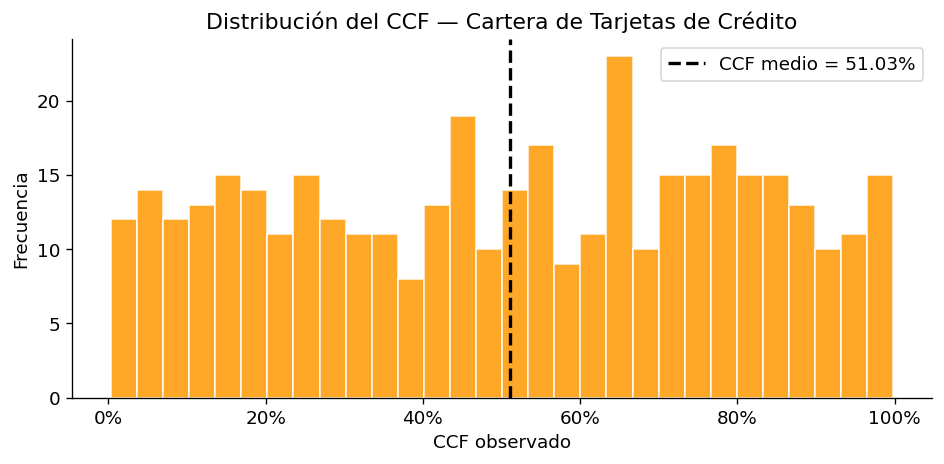


   Clave conceptual:
   Un CCF cercano a 1 indica que los clientes agotan casi toda su línea antes
   de incumplir. Un CCF bajo indica que incumplen con mucho cupo aún disponible.
   Bajo IFRS 9, se recomienda estimar el CCF con datos propios del banco (TTC o PiT).



In [9]:
# Distribución del CCF observado
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(df_ead['ccf_obs'], bins=30, color='#FF9800', edgecolor='white', alpha=0.85)
ax.axvline(ccf_medio, color='black', linestyle='--', linewidth=2,
           label=f'CCF medio = {ccf_medio:.2%}')
ax.set_xlabel('CCF observado')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución del CCF — Cartera de Tarjetas de Crédito')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.legend()
plt.tight_layout()
plt.show()

print("""
   Clave conceptual:
   Un CCF cercano a 1 indica que los clientes agotan casi toda su línea antes
   de incumplir. Un CCF bajo indica que incumplen con mucho cupo aún disponible.
   Bajo IFRS 9, se recomienda estimar el CCF con datos propios del banco (TTC o PiT).
""")

## **3. Integración: LGD y EAD en la Pérdida Esperada IFRS 9**

### **3.1 La Fórmula Central**

Bajo IFRS 9, la **Pérdida Esperada (ECL)** se calcula como:

$$
\boxed{\text{ECL} = \text{PD} \times \text{LGD} \times \text{EAD}}
$$

| Parámetro | ¿Qué mide? | Sesión |
|-----------|-----------|--------|
| **PD** | Probabilidad de que el cliente incumpla | Sesión 15 |
| **LGD** | Fracción de la EAD que se pierde dado el default | Sesión 16 |
| **EAD** | Exposición en el momento del default | Sesión 16 |

Las tres estimaciones son **independientes** y se combinan multiplicativamente.

In [12]:
# ─────────────────────────────────────────────────────────────
# Cálculo de ECL para una cartera mixta
# ─────────────────────────────────────────────────────────────

cartera = pd.DataFrame({
    'cliente_id': ['A001', 'A002', 'A003', 'A004', 'A005'],
    'tipo':       ['Hipoteca', 'Consumo', 'Tarjeta', 'Consumo', 'Hipoteca'],
    'EAD':        [150_000, 12_000, 4_500, 8_000, 200_000],
    'PD':         [0.02, 0.08, 0.15, 0.06, 0.01],
    'LGD':        [0.20, 0.55, 0.75, 0.50, 0.18],
})

cartera['ECL'] = cartera['PD'] * cartera['LGD'] * cartera['EAD']

print(cartera[['cliente_id', 'tipo', 'EAD', 'PD', 'LGD', 'ECL']]
      .to_string(index=False,
                 formatters={
                     'EAD': '${:,.0f}'.format,
                     'PD':  '{:.2%}'.format,
                     'LGD': '{:.2%}'.format,
                     'ECL': '${:,.1f}'.format
                 }))

print(f"\nECL Total de la cartera:  ${cartera['ECL'].sum():,.1f}")
print(f"EAD Total de la cartera:  ${cartera['EAD'].sum():,.0f}")
print(f"Ratio ECL/EAD:            {cartera['ECL'].sum() / cartera['EAD'].sum():.3%}")

cliente_id     tipo      EAD     PD    LGD    ECL
      A001 Hipoteca $150,000  2.00% 20.00% $600.0
      A002  Consumo  $12,000  8.00% 55.00% $528.0
      A003  Tarjeta   $4,500 15.00% 75.00% $506.2
      A004  Consumo   $8,000  6.00% 50.00% $240.0
      A005 Hipoteca $200,000  1.00% 18.00% $360.0

ECL Total de la cartera:  $2,234.2
EAD Total de la cartera:  $374,500
Ratio ECL/EAD:            0.597%


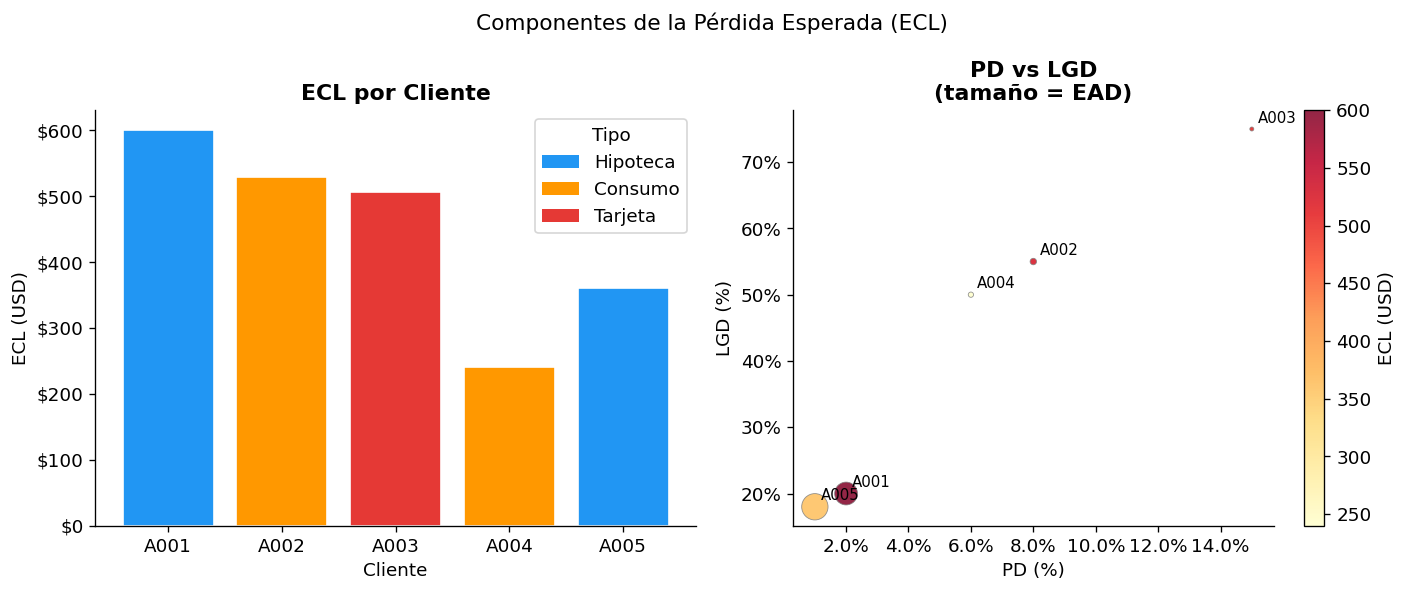

In [13]:
# ─────────────────────────────────────────────────────────────
# Visualización: contribución de cada componente a la ECL
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel izquierdo: ECL por cliente
colores_tipo = {'Hipoteca': '#2196F3', 'Consumo': '#FF9800', 'Tarjeta': '#E53935'}
colores_barra = [colores_tipo[t] for t in cartera['tipo']]

axes[0].bar(cartera['cliente_id'], cartera['ECL'],
            color=colores_barra, edgecolor='white')
axes[0].set_title('ECL por Cliente', fontweight='bold')
axes[0].set_xlabel('Cliente')
axes[0].set_ylabel('ECL (USD)')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Leyenda manual
from matplotlib.patches import Patch
leyenda = [Patch(facecolor=v, label=k) for k, v in colores_tipo.items()]
axes[0].legend(handles=leyenda, title='Tipo')

# Panel derecho: composición PD × LGD como heatmap / scatter
sc = axes[1].scatter(cartera['PD'] * 100, cartera['LGD'] * 100,
                     s=cartera['EAD'] / 800,
                     c=cartera['ECL'], cmap='YlOrRd',
                     edgecolors='gray', linewidths=0.5, alpha=0.85)

for _, row in cartera.iterrows():
    axes[1].annotate(row['cliente_id'],
                     xy=(row['PD'] * 100 + 0.2, row['LGD'] * 100 + 1),
                     fontsize=9)

plt.colorbar(sc, ax=axes[1], label='ECL (USD)')
axes[1].set_xlabel('PD (%)')
axes[1].set_ylabel('LGD (%)')
axes[1].set_title('PD vs LGD\n(tamaño = EAD)', fontweight='bold')
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.suptitle('Componentes de la Pérdida Esperada (ECL)', fontsize=13)
plt.tight_layout()
plt.show()